# Data Split and Analysis (Bhojpuri ASR)

This notebook prepares the Bhojpuri dataset for ASR experiments by:

- loading and validating aligned **.wav + .TextGrid** pairs
- extracting sentence-level transcripts and metadata (duration, speaker, etc.)
- performing dataset **splits** (e.g., LOSO / train–dev–test)
- producing summary statistics and diagnostic plots used in the dissertation

**Output artefacts**
- A split manifest (CSV/JSON) describing train/dev/test membership
- Summary tables and figures for dataset characteristics (duration, utterance length, speaker distribution)


## Reproducibility and execution notes

- All experiment-level parameters are configured in **one place** (the configuration cell below).
- Avoid editing logic in later cells unless required; update configuration values instead.
- This notebook is intended to run end-to-end after a kernel restart.


In [1]:
# Experiment configuration
# ------------------------
# All notebook-level parameters should be modified here only.

CONFIG = {
    # Dataset root (expects .wav and corresponding .TextGrid files)
    "data_root": r"C:\Users\Arun\Documents\Bath\Disseration\03 Data\karya_bhojpuri_data-20250116T173432Z-001\karya_bhojpuri_data\lifecycle",
    "audio_glob": "**/*.wav",
    "font_path" : r"C:\Users\Arun\Documents\Bath\Disseration\01 Experimentation\NotoSansDevanagari-Regular.ttf",

    # Random split parameters (used only if split_strategy == "random")
    "seed": 42,
    "trainval_ratio": 0.9,
    "test_ratio": 0.1,

    # Leave-One-Speaker-Out parameters (used only if split_strategy == "LOSO")
    "test_speaker_id": "281474976710711",           

    # Output paths
    "output_dir": r"/content/drive/My Drive/ASR/analysis_outputs",
    "split_output": r"C:\Users\Arun\Documents\Bath\Disseration\03 Data\trainval_test_split"

}

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Imports
# -------
import glob, os
import torchaudio
import shutil
from pathlib import Path
import librosa.display
import matplotlib.pyplot as plt
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import torch
from jiwer import wer, cer
import pandas as pd
import matplotlib.patches as mpatches
import numpy as np
import re
import json
import torchaudio.sox_effects as sox
import torchaudio
from IPython.display import Audio
import soundfile as sf
import random
import textgrid
from datasets import Dataset, DatasetDict
import evaluate
from tqdm import tqdm
from transformers import pipeline
from transformers import (
AutomaticSpeechRecognitionPipeline,
WhisperTimeStampLogitsProcessor,
WhisperForConditionalGeneration,
WhisperTokenizer,
WhisperProcessor,
)
from transformers import (AutoProcessor, AutoModelForCTC, Trainer, TrainingArguments)
from transformers import DataCollatorWithPadding
split_flag = False 
import math
import warnings
from statistics import mean
from indic_transliteration import sanscript
from indic_transliteration.sanscript import SchemeMap, SCHEMES, transliterate



C:\Users\Arun\anaconda3\envs\whisper-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Utility functions (used throughout)


In [3]:
def load_audio_data(data_path, sample_rate=16000):
    """
    Load an audio waveform and resample to a fixed sampling rate.

    This function ensures consistent audio sampling for downstream
    feature extraction and analysis.
    """
    waveform, sr = torchaudio.load(data_path)

    if sr != sample_rate:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sr,
            new_freq=sample_rate
        )
        waveform = resampler(waveform)

    return waveform

In [4]:
def extract_transcript_from_textgrid(textgrid_path):
    """
    Extract the sentence-level transcription from a Praat TextGrid file.

    This function concatenates non-empty interval labels to reconstruct
    the reference transcript associated with an audio file.
    """
    tg = textgrid.TextGrid.fromFile(textgrid_path)
    tier = tg.tiers[0]

    return " ".join(
        interval.mark.strip()
        for interval in tier.intervals
        if interval.mark.strip()
    )


In [5]:
from dataclasses import dataclass
from typing import Any, Dict, List, Union
import torch

@dataclass
class DataCollatorCTCWithPadding:
    processor: Any
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, Any]:
        input_features = [{"input_values": f["input_values"]} for f in features]
        label_features = [{"input_ids": f["labels"]} for f in features]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt"
        )

        with self.processor.as_target_processor():
            labels_batch = self.processor.pad(
                label_features,
                padding=self.padding,
                return_tensors="pt"
            )

        # Replace padding with -100 to ignore in loss
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        batch["labels"] = labels

        return batch


In [6]:
def infer_indicwav2vec(waveform):
    """
    Perform speech-to-text inference using the IndicWav2Vec model.

    This function applies CTC-based acoustic inference and decodes
    the most likely transcription from the model logits.
    """
    inputs = processor(
        waveform,
        sampling_rate=16000,
        return_tensors="pt"
    )

    with torch.no_grad():
        logits = model(**inputs).logits

    predicted_ids = torch.argmax(logits, dim=-1)
    transcription = processor.batch_decode(predicted_ids)[0]

    return transcription



In [7]:
def process_textgrid(file_path):
    """
    Read and process the Text Grid

    """
    try:
        with open(file_path, "r", encoding="utf-16") as f:
            lines = f.readlines()
    except UnicodeError:
        # Fallback to UTF-8 if UTF-16 fails
        with open(file_path, "r", encoding="utf-8") as f:
            lines = f.readlines()
    #print("lines", lines)

    intervals = []
    interval = {}

    for line in lines:
        line = line.strip() #remove whatespaces

        if line.startswith("xmin ="):
            interval["xmin"] = float(line.split("=")[1].strip())
        elif line.startswith("xmax ="):
            interval["xmax"] = float(line.split("=")[1].strip())
        elif line.startswith('text ='):
            text_match = re.search(r'text = "(.*)"', line)
            interval["text"] = text_match.group(1).strip() if text_match else ""
            #print("interval", interval["text"])


            # Add interval only if it has valid time bounds
            if "xmin" in interval and "xmax" in interval:
                intervals.append(interval)
                interval = {}  # Reset for next interval

    return intervals

In [8]:
def load_textgrid_files(audio_files):
    """
    Load text grid

    """
    vtt_data = []
    for audio_data in audio_files:
        text_file_path = audio_data[0].replace(".wav", ".TextGrid")  # Corresponding text file
        #print("text_file_path", text_file_path)
        vtt_file_data = process_textgrid(text_file_path)
        vtt_data.append(vtt_file_data)

    return vtt_data


In [9]:
def calculate_wer_cer(ground, pred):
    """
    Calculates Word Error Rate (WER) and Character Error Rate (CER) from predicted and ground truth data

    """

    # Make sure the lists are the same length
    assert len(ground) == len(pred), "Mismatch in number of transcriptions."

    # Combine all references and predictions into single strings
    all_references = " ".join(ground)
    all_predictions = " ".join(pred)

    # Calculate WER
    overall_wer = wer(all_references, all_predictions)
    overall_cer = cer(all_references, all_predictions)

    return (overall_wer, overall_cer)


In [10]:
# Compute Log Mel
def compute_log_mel(waveform, sr=16000, n_mels=80):
    """
    Converts raw waveform into log-mel form

    """
    mel = librosa.feature.melspectrogram(y=waveform, sr=sr, n_mels=n_mels)
    return librosa.power_to_db(mel, ref=np.max)


In [11]:
def hindi_syllables(word):
    """
    Counts hindi syllables from characters

    """
    #print("word", word)
    hindi_letts = 'कखगघङचछजझञटठडढणतथदधनपफबभमक़ख़ग़ज़ड़ढ़फ़यरलळवहशषसऱऴअआइईउऊऋॠऌॡएऐओऔॐऍऑऎऒ'
    # List of hindi letters that aren't halves or matras
    count = 0
    for i in word:
        if i in hindi_letts:
            count += 1 if word[word.index(i) - 1] != '्' else 0 # Make sure it's not a half-letter
    #print("count", count)
    return count

In [12]:
def estimate_speaking_rate_from_transcript(transcript, duration):
    """
    Estimate speaking rate, words per second, syllables per second

    """
    words = transcript.strip().split()
    syllables = sum([hindi_syllables(w) for w in words])  # requires syllable counter

    WordsPerSec = len(words) / duration
    SyllablesPerSec = syllables / duration
    return WordsPerSec, SyllablesPerSec


In [13]:
# Classify Gender
def classify_gender(pitch):
    """
    Estimate gender based on the pitch
    Male: < 165
    Female: >=165

    """
    if np.isnan(pitch):
        return 'Unknown'
    elif pitch < 165:
        return 'Male'
    else:
        return 'Female'


In [14]:
def plot_correlations(cers, audio_data, ref_data):
    """
    Plot correlation of various audio attributes to WER/CER

    """

    # Prepare a list to store extracted features
    features = []

    # Process each file in audio_data list
    for i in range(len(cers)):
        waveform = audio_data[i]["audio"]["array"]
        y = waveform.numpy()
        sr = 16000

        # Duration (in seconds)
        duration = len(y) / sr

        # Pitch: use librosa's yin algorithm (more robust than pyin for this task)
        f0 = librosa.yin(y, fmin=50, fmax=500, sr=sr)
        avg_pitch = np.nanmean(f0)

        gender = classify_gender(avg_pitch)

        # WordsPerSec and SyllablesPerSec
        WordsPerSec, SyllablesPerSec = estimate_speaking_rate_from_transcript(ref_data[i], duration)

        # Spectral flatness: high = noise-like, low = harmonic
        flatness = librosa.feature.spectral_flatness(y=y)
        avg_flatness = np.mean(flatness)

        # Store all features
        features.append({
            'File': f'File {i+1}',
            'CER': cers[i],
            'AvgPitch': avg_pitch,
            'WordsPerSec': WordsPerSec,
            'SyllablesPerSec': SyllablesPerSec,
            'Duration': duration,
            'SpectralFlatness': avg_flatness,
            'Gender': gender
        })

    # Create DataFrame
    df = pd.DataFrame(features)

    # Plot correlations
    metrics_to_plot = ['AvgPitch', 'WordsPerSec', 'SyllablesPerSec', 'Duration', 'SpectralFlatness']
    #metrics_to_plot = ['AvgPitch', 'Duration', 'SpectralFlatness']

    # Map gender labels to color codes
    gender_colors = {'Male': 'blue', 'Female': 'red', 'Unknown': 'gray'}
    df['Color'] = df['Gender'].map(gender_colors)

    # Legend for gender-based color coding
    legend_handles = [
        mpatches.Patch(color='blue', label='Male'),
        mpatches.Patch(color='red', label='Female'),
        mpatches.Patch(color='gray', label='Unknown')
    ]
    plt.figure(figsize=(14, 10))
    for i, feature in enumerate(metrics_to_plot):
        plt.subplot(2, 3, i+1)
        plt.scatter(df[feature], df['CER'], color=df['Color'])
        plt.title(f'CER vs {feature}')
        plt.xlabel(feature)
        plt.ylabel('CER')
        # for j in range(len(df)):
        #     plt.annotate(df['File'][j], (df[feature][j], df['CER'][j]), fontsize=8)
        plt.grid(True)
        plt.legend(handles=legend_handles, title="Estimated Gender", loc='upper right', bbox_to_anchor=(1.15, 1), framealpha=0.5)

    plt.suptitle("Correlation of CER with Various Audio Features", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


In [15]:
# Spectrogram for audio files
def plot_spectrogram(audio_data, title="Original Audio"):
    """
    Plot Spectrogram

    """

    # Create 3x2 subplots
    fig, axes = plt.subplots(2, 3, figsize=(8, 6))
    fig.suptitle(f'Log-Mel Spectrograms for {title}', fontsize=16)

    # Plot the spectrogram for the first 6 files in audio_data
    for i in range(6): # hard coding length to avoid exception
        waveform = audio_data[i]["audio"]["array"].numpy()
        spec = compute_log_mel(waveform)

        row = i // 3
        col = i % 3
        ax = axes[row][col]

        img = librosa.display.specshow(spec, sr=16000, x_axis='time', y_axis='mel', ax=ax)
        ax.set_title(f'Audio: {i+1}')
        ax.label_outer()


In [16]:
# Plot spectrogram side by side for audio before and after applying the sugmentation
def plot_spectrogram_side_by_side(audio_data_original, audio_data_aug, title="Augmented"):
    """
    Plot spectrograms for original and augmented audio, side by side

    """
    # Create 2x2 subplots (2 audio files × 2 versions: Original & VTLP)
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    fig.suptitle(f'Original vs {title} Log-Mel Spectrograms', fontsize=16)

    # Plot spectrograms
    for i in range(2):  # Plot for the first 2 files
        # Original
        waveform_orig = audio_data_original[i]["audio"]["array"].numpy()
        spec_orig = compute_log_mel(waveform_orig)

        ax_orig = axes[i][0]
        librosa.display.specshow(spec_orig, sr=16000, x_axis='time', y_axis='mel', ax=ax_orig)
        ax_orig.set_title(f'Original Audio {i+1}')
        ax_orig.label_outer()

        # VTLP Augmented
        waveform_aug = audio_data_aug[i]["audio"]["array"].numpy()
        spec_aug = compute_log_mel(waveform_aug)

        ax_aug = axes[i][1]
        librosa.display.specshow(spec_aug, sr=16000, x_axis='time', y_axis='mel', ax=ax_aug)
        ax_aug.set_title(f'Augmented Audio {i+1}')
        ax_aug.label_outer()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [17]:
# Play the augmented audio
def play_audio(waveform, sample_rate=16000):
    return Audio(waveform, rate=sample_rate)

In [18]:
def transcribe_whisper(audio_tensor, processor, model, device):
    """
    Perform zero-shot Hindi transcription using the Whisper model.

    This function applies encoder–decoder inference with a forced
    Hindi decoding prompt to generate language-specific transcriptions.
    """
    inputs = processor(
        audio_tensor,
        sampling_rate=16000,
        return_tensors="pt"
    ).input_features.to(device)

    forced_ids = processor.get_decoder_prompt_ids(
        language="hi",
        task="transcribe"
    )

    with torch.no_grad():
        predicted_ids = model.generate(
            inputs,
            forced_decoder_ids=forced_ids
        )

    transcription = processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0]

    return transcription


In [19]:
def plot_Error_Rates(wer_scores):
    """
    Visualise Word Error Rate (WER) and Character Error Rate (CER) scores.

    This function generates a grouped bar chart to compare ASR performance
    across different model or augmentation configurations.
    """
    df = pd.DataFrame(wer_scores)

    x = range(len(df))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(
        [i - width / 2 for i in x],
        df["WER"],
        width=width,
        label="WER"
    )
    plt.bar(
        [i + width / 2 for i in x],
        df["CER"],
        width=width,
        label="CER"
    )

    plt.xticks(x, df["type"])
    plt.ylabel("Error Rate")
    plt.title("WER and CER for Each Augmentation Type")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [20]:
def copy_pairs(pairs, dest_folder):
    """
    Copy aligned audio and annotation files to a target directory.

    This function replicates each audio–TextGrid–JSON triplet into the
    specified split folder to create a self-contained dataset structure.
    """
    for wav_path, text_path, json_path in pairs:
        shutil.copy2(wav_path, os.path.join(dest_folder, os.path.basename(wav_path)))
        shutil.copy2(text_path, os.path.join(dest_folder, os.path.basename(text_path)))
        shutil.copy2(json_path, os.path.join(dest_folder, os.path.basename(json_path)))


In [21]:
TEXTGRID_EXT = ".TextGrid"             # paired TextGrid extension
TIER_CANDIDATES = ["Devnagri", "Devanagari"]  # tier names to try (case-insensitive)

# Helper: how to extract speaker_id from path
# Option A: parent directory name (recommended if your data is speaker-foldered)
def speaker_id_from_path(path: str) -> str:
    return os.path.basename(os.path.dirname(path))

# Option B: from filename prefix (e.g., SPK01_XXXX.wav)
# def speaker_id_from_path(path: str) -> str:
#     fname = os.path.basename(path)
#     m = re.match(r"([A-Za-z0-9]+)[_\-].*", fname)
#     return m.group(1) if m else os.path.splitext(fname)[0]

# Map WAV -> TextGrid path
def textgrid_path_for_wav(wav_path: str) -> str:
    base, _ = os.path.splitext(wav_path)
    tg = base + TEXTGRID_EXT
    if os.path.exists(tg):
        return tg
    # Also try lowercase extension
    tg_lower = base + TEXTGRID_EXT.lower()
    return tg_lower if os.path.exists(tg_lower) else None

# ---------- TextGrid parsing ----------
def extract_intervals_from_textgrid(tg_path: str, tier_candidates=TIER_CANDIDATES):
    """
    Returns a list of (xmin, xmax, text) for non-empty intervals in the first matching tier.
    """
    tg = textgrid.TextGrid.fromFile(tg_path)
    # Find the tier
    target_tier = None
    cand_lower = {t.lower() for t in tier_candidates}
    for tier in tg.tiers:
        name = getattr(tier, "name", "") or ""
        if name.lower() in cand_lower:
            target_tier = tier
            break
    # Fallback: if specific tier not found, take first IntervalTier
    if target_tier is None:
        for tier in tg.tiers:
            if tier.__class__.__name__.lower().endswith("intervaltier"):
                target_tier = tier
                break
    if target_tier is None:
        warnings.warn(f"No suitable IntervalTier found in {tg_path}.")
        return []

    rows = []
    # target_tier.intervals: list with .xmin, .xmax, .mark
    for itv in getattr(target_tier, "intervals", []):
        text = (itv.mark or "").strip()
        xmin = float(itv.minTime)
        xmax = float(itv.maxTime)
        if text:  # only keep non-empty
            rows.append((xmin, xmax, text))
    return rows

# ---------- Duration ----------
def wav_duration_seconds(wav_path: str) -> float:
    try:
        with sf.SoundFile(wav_path) as f:
            return len(f) / float(f.samplerate)
    except Exception as e:
        warnings.warn(f"Failed to read duration for {wav_path}: {e}")
        return math.nan



In [22]:
def transliterate_devanagari_to_itrans(text: str) -> str:
    """
    Transliterate Devanagari script to a Romanised representation.

    This function converts Devanagari text into IAST format to enable
    script-independent analysis and comparison.
    """
    return transliterate(
        text,
        sanscript.DEVANAGARI,
        sanscript.IAST
    )

In [23]:
from matplotlib import font_manager
from aksharamukha import transliterate as akshara


# Path to the installed font — adjust if necessary
font_path = CONFIG["font_path"]
# Register and set globally
font_manager.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Noto Sans Devanagari'
plt.rcParams['font.sans-serif'] = ['Noto Sans Devanagari']

def plot_waveform_and_logmel(
    wav_path: str,
    transcript: str,
    sr_target: int = 16000,
    n_mels: int = 80,
    fmin: int = 20,
    fmax: int = 7600,
    save_path: str = r"C:\Users\Arun\Documents\Bath\Disseration\Plots\waveform_logmel"  
):
    # Load audio
    y, sr = librosa.load(wav_path, sr=sr_target, mono=True)
    duration = len(y) / sr

    latn_text = transliterate_devanagari_to_itrans(transcript) if transcript else ""
    #latn_text = akshara.process('Devanagari', 'Latin', transcript)


    # Compute log-Mel
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels, fmin=fmin, fmax=fmax, power=2.0
    )
    S_db = librosa.power_to_db(S, ref=np.max)

    # Create figure
    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [1, 1.4, 0.4]}
    )

    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=ax1, color="#2c7fb8")
    ax1.set_title("Waveform", fontsize=12, weight="bold")
    ax1.set_xlim(0, duration)
    ax1.set_ylabel("Amplitude")

    # Log-Mel
    img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel",
                                   fmin=20, fmax=7600, cmap="magma", ax=ax2)
    ax2.set_title("Log-Mel Spectrogram", fontsize=12, weight="bold")
    fig.colorbar(img, ax=ax2, format="%+2.0f dB", label="dB")


    ax3.axis("off")
    caption = (f"Transcript (Devanagari): {transcript}\n"
               f"Transliteration (ITRANS): {latn_text}\n"
               f"File: {os.path.basename(wav_path)} | Duration: {duration:.2f}s")
    ax3.text(0.01, 0.95, caption, fontsize=16, va="top", wrap=True)

    plt.subplots_adjust(hspace=0.5)
    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return {"wav": wav_path, "transcript": transcript, "translit": latn_text, "duration_s": duration}


---
End of utility function definitions.  
The remainder of the notebook executes the fine-tuning pipeline in a linear, top-down order.

# Dataset Split (LOSO)

The dataset is partitioned using a **Leave-One-Speaker-Out (LOSO)** strategy to ensure
speaker-independent evaluation. All audio–annotation pairs belonging to a single
held-out speaker are assigned to the test set, while data from all remaining speakers
are grouped into a `trainval` set. The `trainval` split is used for fine-tuning and
validation in the **fine-tuning notebook**, while the `test` split is used exclusively
for model evaluation and result reporting in the **inference notebook**.


In [24]:
# Leave-One-Speaker-Out (LOSO) cross-validation

def copy_pairs(pairs, destination_folder):
    for wav_file, text_file, json_file in pairs:
        for f in [wav_file, text_file, json_file]:
            shutil.copy(f, destination_folder)

# ----------------- CONFIG -----------------
split_flag = True
root_folder = CONFIG["data_root"]
output_base = CONFIG["split_output"]

# Pick a test speaker (folder name)
test_speaker = CONFIG["test_speaker_id"] 
# ------------------------------------------

if split_flag:
    train_folder = os.path.join(output_base, "trainval")
    test_folder = os.path.join(output_base, "test")
    
    os.makedirs(train_folder, exist_ok=True)
    os.makedirs(test_folder, exist_ok=True)
    
    # Collect all speaker folders
    speaker_folders = [os.path.join(root_folder, d) for d in os.listdir(root_folder)
                       if os.path.isdir(os.path.join(root_folder, d))]
    
    train_pairs = []
    test_pairs = []

    for speaker_path in speaker_folders:
        speaker_name = os.path.basename(speaker_path)
        is_test = (speaker_name == test_speaker)
        
        for wav_file in glob.glob(os.path.join(speaker_path, "*.wav")):
            base_name = os.path.splitext(os.path.basename(wav_file))[0]
            text_file = os.path.join(speaker_path, base_name + ".TextGrid")
            json_file = os.path.join(speaker_path, base_name + ".json")
            
            if os.path.exists(text_file) and os.path.exists(json_file):
                pair = (wav_file, text_file, json_file)
                if is_test:
                    test_pairs.append(pair)
                else:
                    train_pairs.append(pair)
    
    print(f"Test speaker: {test_speaker}")
    print(f"Train pairs: {len(train_pairs)}")
    print(f"Test pairs: {len(test_pairs)}")
    
    copy_pairs(train_pairs, train_folder)
    copy_pairs(test_pairs, test_folder)


Test speaker: 281474976710711
Train pairs: 344
Test pairs: 39


# Dataset Analysis

This section provides a descriptive analysis of the Bhojpuri speech dataset used in
this study. File-level statistics such as audio duration, number of sentences, and
word counts are computed from aligned `.wav` and `.TextGrid` files, while missing
annotations are handled gracefully. Speaker-level aggregates
are then derived to summarise data distribution across speakers, supporting an
informed interpretation of training data coverage and evaluation results.


In [25]:


# ---------- Collect file-level stats ----------
file_records = []

wav_paths = glob.glob(os.path.join(CONFIG["data_root"], CONFIG["audio_glob"]), recursive=True)
wav_paths = sorted(wav_paths)

if not wav_paths:
    print("No WAV files found. Check DATA_DIR and AUDIO_GLOB.")

for wav in wav_paths:
    spk = speaker_id_from_path(wav)
    dur = wav_duration_seconds(wav)
    tg = textgrid_path_for_wav(wav)

    num_sentences = 0
    num_words = 0
    sent_durations = []
    words_per_sentence = []

    if tg and os.path.exists(tg):
        intervals = extract_intervals_from_textgrid(tg)
        for (xmin, xmax, text) in intervals:
            seg_dur = max(0.0, float(xmax) - float(xmin))
            tokens = text.split()  # Devanagari tokenization by whitespace is fine for counts
            if text.strip():
                num_sentences += 1
                num_words += len(tokens)
                sent_durations.append(seg_dur)
                words_per_sentence.append(len(tokens))
    else:
        warnings.warn(f"Missing TextGrid for {wav}; sentence/word stats will be NaN.")

    avg_sent_dur = mean(sent_durations) if sent_durations else math.nan
    max_sent_dur = max(sent_durations) if sent_durations else math.nan
    avg_wps = mean(words_per_sentence) if words_per_sentence else math.nan
    max_wps = max(words_per_sentence) if words_per_sentence else math.nan

    file_records.append({
        "speaker_id": spk,
        "audio_file": os.path.basename(wav),
        "duration_s": dur,
        "num_sentences": num_sentences,
        "num_words": num_words,
        "avg_sentence_duration_s": avg_sent_dur,
        "max_sentence_duration_s": max_sent_dur,
        "avg_words_per_sentence": avg_wps,
        "max_words_per_sentence": max_wps,
    })

df_files = pd.DataFrame(file_records)

# ---------- Build speaker-level summary ----------
agg = df_files.groupby("speaker_id").agg(
    total_duration_s=("duration_s", "sum"),
    num_files=("audio_file", "count"),
    avg_file_duration_s=("duration_s", "mean"),
    min_file_duration_s=("duration_s", "min"),
    max_file_duration_s=("duration_s", "max"),
).reset_index()

df_speakers = agg.copy()

# (Optional) Save to CSV
# df_files.to_csv("bhojpuri_file_level_stats.csv", index=False)
# df_speakers.to_csv("bhojpuri_speaker_level_stats.csv", index=False)



In [26]:
df_speakers.head(10)

,speaker_id,total_duration_s,num_files,avg_file_duration_s,min_file_duration_s,max_file_duration_s
0,281474976710710,567.055875,39,14.539894,1.857625,51.432250
1,281474976710711,716.639000,39,18.375359,2.438125,84.009875
2,281474976710713,604.858125,39,15.509183,3.738500,40.286625
3,281474976710714,1167.663250,39,29.940083,2.298875,95.712750
4,281474976710715,447.264500,45,9.939211,0.023250,21.501750
5,281474976710717,1277.516875,39,32.756843,7.848375,72.330250
6,281474976710718,309.616625,39,7.938888,0.255500,30.069875
7,281474976710719,223.237875,39,5.724048,3.111500,10.147125
8,281474976710742,786.972000,39,20.178769,5.712125,95.132250
9,281474976710748,906.461875,39,23.242612,4.945875,80.805375


In [27]:
df_files.head()

,speaker_id,audio_file,duration_s,num_sentences,num_words,avg_sentence_duration_s,max_sentence_duration_s,avg_words_per_sentence,max_words_per_sentence
0,281474976710710,281474976733393.wav,20.874750,3,40,5.985163,6.68098,13.333333,16.0
1,281474976710710,281474976733394.wav,42.330000,5,92,7.780248,12.98834,18.400000,30.0
2,281474976710710,281474976733395.wav,37.291250,6,74,5.330012,7.83217,12.333333,17.0
3,281474976710710,281474976733396.wav,17.136375,3,44,4.886110,6.53780,14.666667,20.0
4,281474976710710,281474976733397.wav,33.065250,5,72,6.023982,7.70285,14.400000,21.0


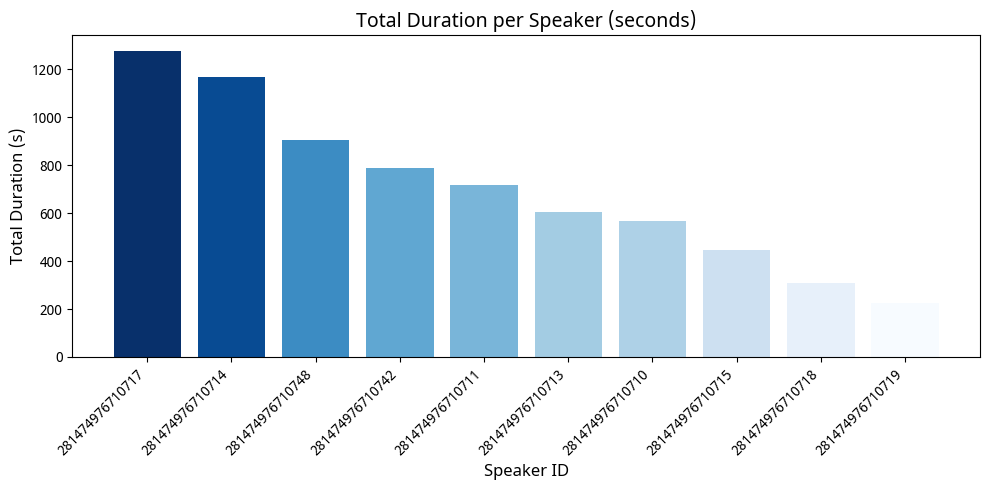

In [28]:

# Sort speakers by total duration descending
plot_df = df_speakers.sort_values("total_duration_s", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    plot_df["speaker_id"],
    plot_df["total_duration_s"],
    color=plt.cm.Blues((plot_df["total_duration_s"] - plot_df["total_duration_s"].min() + 1) /
                       (plot_df["total_duration_s"].max() - plot_df["total_duration_s"].min() + 1e-8 +1))
)
plt.title("Total Duration per Speaker (seconds)", fontsize=14, weight="bold")
plt.xlabel("Speaker ID", fontsize=12)
plt.ylabel("Total Duration (s)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"C:\Users\Arun\Documents\Bath\Disseration\Plots\speaker_dist", dpi=300, bbox_inches="tight")

# High-res save for dissertation
# plt.savefig("img/speaker_total_duration.png", dpi=300, bbox_inches="tight")
plt.show()


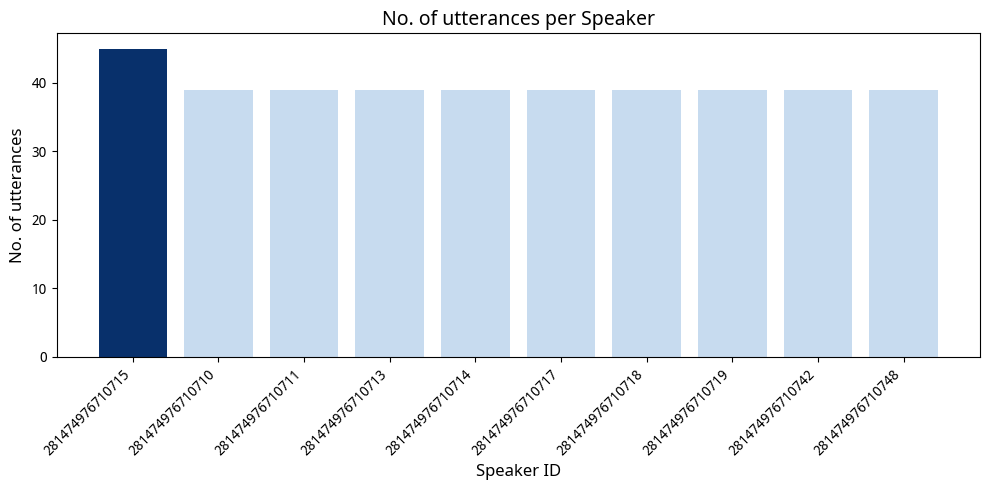

In [29]:

# Sort speakers by total duration descending
plot_df = df_speakers.sort_values("num_files", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    plot_df["speaker_id"],
    plot_df["num_files"],
    color=plt.cm.Blues((plot_df["num_files"] - plot_df["num_files"].min() + 2) /
                       (plot_df["num_files"].max() - plot_df["num_files"].min() + 1e-8 + 2))
)
plt.title("No. of utterances per Speaker", fontsize=14, weight="bold")
plt.xlabel("Speaker ID", fontsize=12)
plt.ylabel("No. of utterances", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"C:\Users\Arun\Documents\Bath\Disseration\Plots\speaker_utterances.png", dpi=300, bbox_inches="tight")

# High-res save for dissertation
# plt.savefig("img/speaker_total_duration.png", dpi=300, bbox_inches="tight")
plt.show()

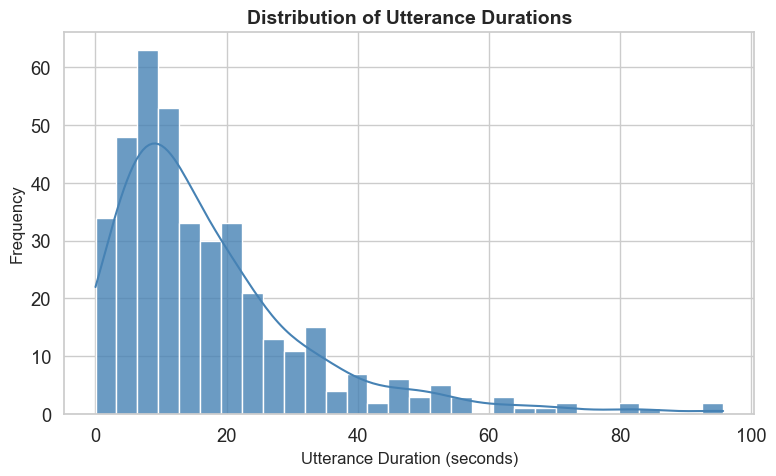

In [30]:
import seaborn as sns

# Filter to remove any missing or zero-duration entries
durations = df_files["duration_s"].dropna()
durations = durations[durations > 0]

plt.figure(figsize=(8, 5))
sns.set(style="whitegrid", font_scale=1.2)

# Histogram
sns.histplot(
    durations,
    bins=30,
    kde=True,
    color="steelblue",
    edgecolor=None,
    alpha=0.8
)

# Labels and title
plt.title("Distribution of Utterance Durations", fontsize=14, weight="bold")
plt.xlabel("Utterance Duration (seconds)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.savefig(r"C:\Users\Arun\Documents\Bath\Disseration\Plots\utterance_hist.png", dpi=300, bbox_inches="tight")

# Save high-resolution version for dissertation
# plt.savefig("img/utterance_duration_histogram.png", dpi=300, bbox_inches='tight')

plt.show()


# Tokenizer coverage analysis (Bhojpuri-specific symbols)

This section checks whether the pretrained model’s tokenizer can represent the Bhojpuri transcripts in the dataset without losing information.

Although Bhojpuri is written primarily in **Devanagari**, practical corpora often contain additional symbols (e.g., nukta/diacritics, punctuation, orthographic variants, or corpus-specific marks). If such characters are **not present in the base tokenizer vocabulary**, they may be mapped to an unknown token or dropped during encoding, which can degrade CTC training and increase decoding errors.

The goal of this analysis is therefore to:
- scan the Bhojpuri transcripts and extract the set of unique characters used,
- compare this set against the pretrained tokenizer’s known symbols,
- identify any **out-of-vocabulary characters**,
- and select a small, justified set of missing symbols to add during tokenizer adaptation.

In this study, this procedure revealed **four missing symbols** that were subsequently added to the tokenizer as part of the language-specific adaptation stage during fine tuning.


In [31]:
root_path = CONFIG["split_output"]

paired_files = train_pairs + test_pairs


manifest_data = []
for pairs in paired_files:
    for fname in pairs:
        if fname.endswith(".wav"):
            wav_path = os.path.join(root_path, fname)
            tg_path = wav_path.replace(".wav", ".TextGrid")
            if os.path.exists(tg_path):
                transcript = extract_transcript_from_textgrid(tg_path)
                waveform = load_audio_data(wav_path)
                manifest_data.append({"path": wav_path, "transcription": transcript, "audio": {"array": waveform.squeeze(0), "sampling_rate": 16000}})

In [32]:


data_dir = CONFIG["data_root"]

# Create a DataFrame from the manifest list
df_manifest = pd.DataFrame(manifest_data)

# Normalize file paths to the same relative format used in df_files
def normalize_path(p):
    # Convert to relative path using the same base directory as df_files
    return os.path.basename(p)

df_manifest["audio_file"] = df_manifest["path"].apply(normalize_path)

# 3️Select only necessary columns
df_manifest = df_manifest[["audio_file", "transcription"]]

# Merge with df_files on 'audio_file'
df_files = df_files.merge(df_manifest, on="audio_file", how="left")

# Verify merge result

print(f"Merged transcripts for {df_files['transcription'].notna().sum()} / {len(df_files)} files.")


Merged transcripts for 383 / 396 files.


In [33]:
df_files.head(2)["transcription"]

0    सबसे पहिले जब लइका जनम लेवेला त एक या दू दिन क...
1    ई कुल काम पतरा देख के सुभ मुहुरत मे होयला जइसे...
Name: transcription, dtype: object

In [34]:
#plot_spectrogram(test_data)

In [35]:
# Tokenise (split on whitespace)
df_files["tokens"] = df_files["transcription"].apply(lambda x: str(x).split())

# Flatten all tokens
all_tokens = [token for sublist in df_files["tokens"] for token in sublist]

# --- Compute statistics ---
total_tokens = len(all_tokens)
unique_tokens = len(set(all_tokens))
type_token_ratio = unique_tokens / total_tokens if total_tokens > 0 else np.nan
avg_chars_per_token = np.mean([len(token) for token in all_tokens]) if all_tokens else np.nan

# Create summary dataframe
token_stats = pd.DataFrame({
    "Statistic": [
        "Total tokens",
        "Unique tokens",
        "Type–token ratio",
        "Avg. characters per token"
    ],
    "Value": [
        f"{total_tokens:,}",
        f"{unique_tokens:,}",
        f"{type_token_ratio:.2f}",
        f"{avg_chars_per_token:.2f}"
    ]
})

# Display neatly
print(token_stats.to_string(index=False))


                Statistic  Value
             Total tokens 12,532
            Unique tokens  2,296
         Type–token ratio   0.18
Avg. characters per token   3.57


In [36]:
print(token_stats.to_latex(index=False, caption="Token and Character Statistics", label="tab:token_stats"))

\begin{table}
\caption{Token and Character Statistics}
\label{tab:token_stats}
\begin{tabular}{ll}
\toprule
Statistic & Value \\
\midrule
Total tokens & 12,532 \\
Unique tokens & 2,296 \\
Type–token ratio & 0.18 \\
Avg. characters per token & 3.57 \\
\bottomrule
\end{tabular}
\end{table}



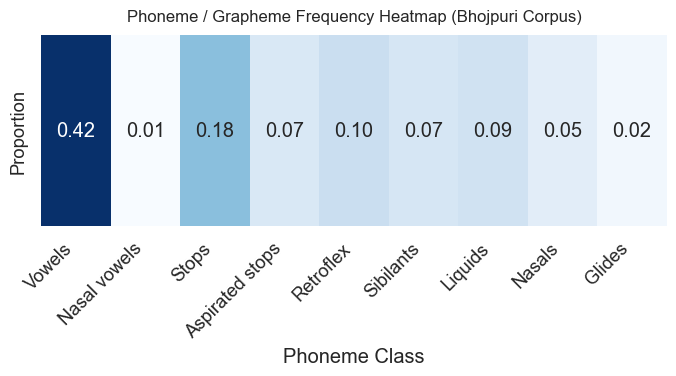

In [37]:
from collections import Counter


# --- 1. Extract text data ---
# Assumes df_files (or merged df) has a column 'transcription' with Devanagari text
texts = df_files["transcription"].dropna().tolist()

# --- 2. Convert Devanagari → ITRANS (or HK) to make phoneme-level analysis easier ---
itrans_texts = [transliterate(t, sanscript.DEVANAGARI, sanscript.ITRANS) for t in texts]

# --- 3. Define basic Bhojpuri phoneme/grapheme classes (simplified) ---
# You can adjust this mapping later for more precise phoneme sets
phoneme_classes = {
    "Vowels": r"[aAiIuUeEoO]",
    "Nasal vowels": r"~N|M",
    "Stops": r"[kKgGcCjJTDtdpb]",
    "Aspirated stops": r"[KhGhChJhThDhPhBh]",
    "Retroflex": r"[TtDdhR]",
    "Sibilants": r"[sSh]",
    "Liquids": r"[lr]",
    "Nasals": r"[nNm]",
    "Glides": r"[yHv]",
}

# --- 4. Count phonemes per class ---
def count_phoneme_classes(text, classes):
    counts = {k: 0 for k in classes}
    for cls, pattern in classes.items():
        counts[cls] += len(re.findall(pattern, text))
    return counts

phoneme_counts = [count_phoneme_classes(t, phoneme_classes) for t in itrans_texts]
df_phoneme = pd.DataFrame(phoneme_counts).sum().to_frame("Count")
df_phoneme["Proportion"] = df_phoneme["Count"] / df_phoneme["Count"].sum()

# --- 5. Plot heatmap ---
plt.figure(figsize=(7, 4))
sns.heatmap(
    df_phoneme[["Proportion"]].T,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=False,
)
plt.title("Phoneme / Grapheme Frequency Heatmap (Bhojpuri Corpus)", fontsize=12, pad=10)
plt.xlabel("Phoneme Class")
plt.ylabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"C:\Users\Arun\Documents\Bath\Disseration\Plots\phoneme_heatmap.png", dpi=300, bbox_inches="tight")


plt.show()



In [38]:
df_phoneme

,Count,Proportion
Vowels,27892,0.415920
Nasal vowels,414,0.006173
Stops,12050,0.179687
Aspirated stops,4541,0.067714
Retroflex,6728,0.100327
Sibilants,4980,0.074261
Liquids,5811,0.086652
Nasals,3340,0.049805
Glides,1305,0.019460


### Tokenizer analysis ##


In [39]:
import re
import pandas as pd
from transformers import Wav2Vec2Processor

# -------------------------------------------------------------
# Combine all transcripts from your dataframe
# -------------------------------------------------------------
# Assuming df_files["transcription"] is a list/column of strings
all_text = " ".join(df_files["transcription"].astype(str).tolist())

# -------------------------------------------------------------
# Load Hindi IndicWav2Vec tokenizer
# -------------------------------------------------------------
processor = Wav2Vec2Processor.from_pretrained("ai4bharat/indicwav2vec-hindi")
hindi_vocab = set(processor.tokenizer.get_vocab().keys())

print(f"Hindi tokenizer size: {len(hindi_vocab)}")

# -------------------------------------------------------------
# Extract unique Devanagari characters from Bhojpuri corpus
# -------------------------------------------------------------
def extract_unique_chars(text):
    # Keep only Devanagari characters (U+0900–U+097F)
    text = re.sub(r"[^\u0900-\u097F\s]", "", text)
    chars = sorted(set(text.replace(" ", "")))
    return chars

bhojpuri_chars = extract_unique_chars(all_text)
print(f"Unique Devanagari characters in Bhojpuri corpus: {len(bhojpuri_chars)}")

# -------------------------------------------------------------
# Filter Hindi tokenizer symbols to Devanagari characters
# -------------------------------------------------------------
hindi_chars = [tok for tok in hindi_vocab if re.match(r"^[\u0900-\u097F]+$", tok)]

# -------------------------------------------------------------
# Find Bhojpuri characters not present in Hindi tokenizer
# -------------------------------------------------------------
missing_chars = sorted(set(bhojpuri_chars) - set(hindi_chars))

print("Bhojpuri characters NOT present in Hindi IndicWav2Vec tokenizer (excluding punctuation):")
print(missing_chars)
print(f"Total new chars to add: {len(missing_chars)}")


C:\Users\Arun\anaconda3\envs\whisper-env\lib\site-packages\transformers\models\wav2vec2\processing_wav2vec2.py:61: FutureWarning: Loading a tokenizer inside Wav2Vec2Processor from a config that does not include a `tokenizer_class` attribute is deprecated and will be removed in v5. Please add `'tokenizer_class': 'Wav2Vec2CTCTokenizer'` attribute to either your `config.json` or `tokenizer_config.json` file to suppress this warning: 
  warnings.warn(


Hindi tokenizer size: 68
Unique Devanagari characters in Bhojpuri corpus: 59
Bhojpuri characters NOT present in Hindi IndicWav2Vec tokenizer (excluding punctuation):
['ऒ', 'ऽ', 'ॄ', 'ॆ']
Total new chars to add: 4


In [40]:
print(f"Hindi Tokenizer: {sorted(hindi_vocab)}")
print(f"Bhojpuri Tokens (excl. '</s>', '<pad>', '<s>', '<unk>', '|'  : {sorted(bhojpuri_chars)}")


Hindi Tokenizer: ['</s>', '<pad>', '<s>', '<unk>', '|', 'ँ', 'ं', 'ः', 'अ', 'आ', 'इ', 'ई', 'उ', 'ऊ', 'ऋ', 'ए', 'ऐ', 'ऑ', 'ओ', 'औ', 'क', 'ख', 'ग', 'घ', 'ङ', 'च', 'छ', 'ज', 'झ', 'ञ', 'ट', 'ठ', 'ड', 'ढ', 'ण', 'त', 'थ', 'द', 'ध', 'न', 'प', 'फ', 'ब', 'भ', 'म', 'य', 'र', 'ल', 'ळ', 'व', 'श', 'ष', 'स', 'ह', '़', 'ा', 'ि', 'ी', 'ु', 'ू', 'ृ', 'ॅ', 'े', 'ै', 'ॉ', 'ो', 'ौ', '्']
Bhojpuri Tokens (excl. '</s>', '<pad>', '<s>', '<unk>', '|'  : ['ँ', 'ं', 'ः', 'अ', 'आ', 'इ', 'ई', 'उ', 'ऊ', 'ए', 'ऒ', 'ओ', 'औ', 'क', 'ख', 'ग', 'घ', 'च', 'छ', 'ज', 'झ', 'ट', 'ठ', 'ड', 'ढ', 'ण', 'त', 'थ', 'द', 'ध', 'न', 'प', 'फ', 'ब', 'भ', 'म', 'य', 'र', 'ल', 'व', 'श', 'ष', 'स', 'ह', '़', 'ऽ', 'ा', 'ि', 'ी', 'ु', 'ू', 'ृ', 'ॄ', 'ॆ', 'े', 'ै', 'ो', 'ौ', '्']
